In [9]:
%matplotlib inline

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import least_squares
from scipy.linalg import expm, solve_continuous_lyapunov

plt.rcParams.update({
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

CWD = Path.cwd().resolve()
if (CWD / "germany" / "germany23+24+25" / "data" / "seasonality" / "german_panel.csv").exists():
    CODE = CWD / "germany" / "germany23+24+25"
elif (CWD / "data" / "seasonality" / "german_panel.csv").exists():
    CODE = CWD
else:
    raise FileNotFoundError("Run this notebook from the repo root or from germany/germany23+24+25/. Run notebook 01 first.")

DATA = CODE / "data"
OUT = DATA / "kalman"
FIG = CODE / "figures"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

pr = pd.read_csv(DATA / "seasonality" / "german_panel.csv", index_col=0)["log_price_resid"].to_numpy(float)
pr = pr[np.isfinite(pr)]
pr = pr - pr.mean()
N = len(pr)
v0 = float(pr @ pr / N)

def acf(k):
    k = int(k)
    return 1.0 if k == 0 else float(pr[:-k] @ pr[k:] / ((N - k) * v0))

# Fit horizon: dense hourly ACF up to 14 days.
lags_fit = np.arange(1, 337)  # 1h ... 336h = 14 days

# Diagnostic horizon: keep the old long-lag grid, but do not fit on it.
lags_diag = np.concatenate([
    np.arange(1, 337),
    np.array([384, 432, 504, 600, 720, 960, 1200, 1440, 1800, 2160, 2520]),
])

# Backward-compatible names used by the calibration code below.
lags = lags_fit
rho_emp = np.array([acf(k) for k in lags])
nlag = len(lags)

# Weights for the 14-day fit.
# Stronger emphasis on intraday and first few days; no long-lag overweight.
wts = 1 / np.sqrt(lags.astype(float))
wts[lags <= 72] *= 2.0
for anchor in [1, 2, 3, 6, 12, 18, 24, 30, 48, 72, 96, 120, 144, 168, 240, 336]:
    wts[lags == anchor] *= 6.0
sw = np.sqrt(wts / wts.mean())

def softmax(z):
    z = np.asarray(z, dtype=float)
    z = z - z.max()
    e = np.exp(z)
    return e / e.sum()

print(f"{N:,} hourly deseasonalised log-price residuals")
print(f"variance target v0 = {v0:.6e}")
print(f"ACF fit target: {nlag} lags, 1h to {lags.max()}h ({lags.max()/24:.1f} days)")
print(f"ACF diagnostic grid: 1h to {lags_diag.max()}h ({lags_diag.max()/24:.1f} days)")

26,305 hourly deseasonalised log-price residuals
variance target v0 = 1.256839e-03
ACF fit target: 336 lags, 1h to 336h (14.0 days)
ACF diagnostic grid: 1h to 2520h (105.0 days)


Best half-lives h: [  1.904  20.018 283.142 125.14 ]
Active upper bound: [False False False False]
Max half-life h: 720.0
Optimizer status: 2 `ftol` termination condition is satisfied.


kind,half_life_h,half_life_d,period_h,share
osc,125.14,5.21,24.0,0.059
real,1.90,0.08,inf,0.224
real,20.02,0.83,inf,0.517
real,283.14,11.80,inf,0.200


RMSE=0.019796  WSSR=0.1733  (CARMA order 5)


lag_h,empirical,model,err
1,0.9332,0.9111,-0.0221
2,0.8402,0.8399,-0.0003
3,0.7650,0.7805,+0.0154
6,0.6222,0.6420,+0.0198
12,0.5136,0.4829,-0.0307
18,0.4529,0.4687,+0.0158
24,0.5224,0.4652,-0.0572
30,0.3249,0.3686,+0.0437
48,0.3143,0.3209,+0.0066
72,0.2722,0.2498,-0.0224


Long-lag diagnostics only; these lags were not used in calibration.


lag_h,days,empirical,model,err
384,16.0,0.1354,0.0851,-0.0503
432,18.0,0.0984,0.0748,-0.0236
504,21.0,0.1032,0.0618,-0.0414
600,25.0,0.0805,0.0481,-0.0323
720,30.0,0.0914,0.0354,-0.0560
960,40.0,0.1505,0.0193,-0.1312
1200,50.0,0.1137,0.0107,-0.1031
1440,60.0,0.0832,0.0059,-0.0773
1800,75.0,0.0929,0.0024,-0.0905
2160,90.0,0.0795,0.0010,-0.0785


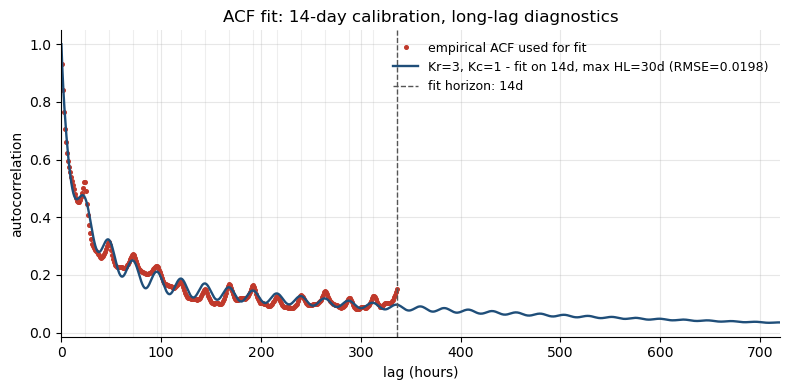

In [12]:
# ── Kr=3, Kc=1 with fixed 24h period ─────────────────────────────
# Adds one real eigenvalue relative to the previous Kr=2,Kc=1 run.
Kr, Kc = 3, 1
m = Kr + Kc
om_c_fixed = np.array([2 * np.pi / 24.0])

def rho_24(theta, k):
    # ACF model with Kr real modes and one fixed daily oscillatory pair.
    kap = np.log(2) / np.exp(theta[:m])
    sh = softmax(theta[m:2 * m])
    h = np.asarray(k, dtype=float)

    out = np.zeros_like(h, dtype=float)
    for i in range(Kr):
        out += sh[i] * np.exp(-kap[i] * h)
    for j in range(Kc):
        idx = Kr + j
        out += sh[idx] * np.exp(-kap[idx] * h) * np.cos(om_c_fixed[j] * h)
    return out

# All half-lives are bounded above so the slowest eigenvalue is <= 30 days.
# The oscillatory half-life remains constrained to >= 2 days.
max_half_life_h = 30.0 * 24.0
lb_hl = [np.log(0.3)] * Kr + [np.log(12.0)] * Kc
ub_hl = [np.log(max_half_life_h)] * m
lb = lb_hl + [-9.0] * m
ub = ub_hl + [9.0] * m

start_hl = [
    [2.0, 24.0, 180.0, 72.0],
    [4.0, 36.0, 240.0, 96.0],
    [1.0, 12.0, 120.0, 48.0],
    [6.0, 48.0, 360.0, 120.0],
    [3.0, 30.0, 600.0, 96.0],
]

rng = np.random.default_rng(42)
best = None
n_starts = 64
for s in range(n_starts):
    if s < len(start_hl):
        xs = np.r_[np.log(start_hl[s]), [0.0] * m]
    else:
        xs = np.r_[np.log(start_hl[s % len(start_hl)]), [0.0] * m]
        xs[:m] += rng.normal(0, 0.55, m)
        xs[m:2 * m] += rng.normal(0, 1.1, m)
    xs = np.clip(xs, lb, ub)
    r = least_squares(
        lambda t: sw * (rho_24(t, lags) - rho_emp),
        xs,
        bounds=(lb, ub),
        max_nfev=7000,
    )
    if best is None or r.cost < best.cost:
        best = r

kap_b = np.log(2) / np.exp(best.x[:m])
sh_b = softmax(best.x[m:2 * m])
hl_best = np.exp(best.x[:m])
active_upper = np.isclose(hl_best, max_half_life_h, rtol=0, atol=1e-4)

print("Best half-lives h:", np.round(hl_best, 3))
print("Active upper bound:", active_upper)
print("Max half-life h:", max_half_life_h)
print("Optimizer status:", best.status, best.message)

rows = []
for i in range(Kr):
    hl_h = np.log(2) / kap_b[i]
    rows.append({
        "kind": "real",
        "half_life_h": hl_h,
        "half_life_d": hl_h / 24.0,
        "period_h": np.inf,
        "share": sh_b[i],
    })
for j in range(Kc):
    idx = Kr + j
    hl_h = np.log(2) / kap_b[idx]
    rows.append({
        "kind": "osc",
        "half_life_h": hl_h,
        "half_life_d": hl_h / 24.0,
        "period_h": 24.0,
        "share": sh_b[idx],
    })

summary_24 = pd.DataFrame(rows).sort_values(["kind", "half_life_h"]).reset_index(drop=True)
display(summary_24.style.format({
    "half_life_h": "{:.2f}",
    "half_life_d": "{:.2f}",
    "period_h": "{:.1f}",
    "share": "{:.3f}",
}).hide(axis="index"))

rmse_24 = float(np.sqrt(np.mean((rho_24(best.x, lags) - rho_emp) ** 2)))
wssr_24 = float(np.sum((sw * (rho_24(best.x, lags) - rho_emp)) ** 2))
print(f"RMSE={rmse_24:.6f}  WSSR={wssr_24:.4f}  (CARMA order {Kr + 2 * Kc})")

diag = [1, 2, 3, 6, 12, 18, 24, 30, 48, 72, 96, 120, 144, 168, 240, 336]
cmp = pd.DataFrame({
    "lag_h": diag,
    "empirical": [acf(k) for k in diag],
    "model": rho_24(best.x, np.array(diag, dtype=float)),
})
cmp["err"] = cmp["model"] - cmp["empirical"]
display(cmp.style.format({"empirical": "{:.4f}", "model": "{:.4f}", "err": "{:+.4f}"}).hide(axis="index"))

diag_long = [384, 432, 504, 600, 720, 960, 1200, 1440, 1800, 2160, 2520]
cmp_long = pd.DataFrame({
    "lag_h": diag_long,
    "days": np.array(diag_long) / 24.0,
    "empirical": [acf(k) for k in diag_long],
    "model": rho_24(best.x, np.array(diag_long, dtype=float)),
})
cmp_long["err"] = cmp_long["model"] - cmp_long["empirical"]

print("Long-lag diagnostics only; these lags were not used in calibration.")
display(cmp_long.style.format({
    "days": "{:.1f}",
    "empirical": "{:.4f}",
    "model": "{:.4f}",
    "err": "{:+.4f}",
}).hide(axis="index"))

kk = np.arange(0, 721)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, 337), [acf(k) for k in range(1, 337)],
        "o", ms=2.6, color="#c0392b", label="empirical ACF used for fit")
ax.plot(kk, rho_24(best.x, kk), "-", lw=1.7, color="#1f4e79",
        label=f"Kr=3, Kc=1 - fit on 14d, max HL=30d (RMSE={rmse_24:.4f})")
for d in range(24, 337, 24):
    ax.axvline(d, color="#eee", lw=0.8, zorder=0)
ax.axvline(336, color="#555555", lw=1.0, ls="--", label="fit horizon: 14d")
ax.set_xlim(0, 720)
ax.set_xlabel("lag (hours)")
ax.set_ylabel("autocorrelation")
ax.set_title("ACF fit: 14-day calibration, long-lag diagnostics")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

Fixed slow real half-life = 2880.0 h = 120.0 d
ACF calibration lags: 350
  short dense lags: 1..336 h
  long anchors h: [384, 432, 504, 600, 720, 960, 1200, 1440, 1800, 2160, 2520, 2880, 3600, 4320]
Best half-lives h [real fast, real mid, real slow fixed, osc]: [2.63100e+00 2.86890e+01 2.88000e+03 1.73114e+02]
Best half-lives d [real fast, real mid, real slow fixed, osc]: [1.100e-01 1.195e+00 1.200e+02 7.213e+00]
Active upper bound: [False False False False]
Optimizer status: 3 `xtol` termination condition is satisfied.


kind,half_life_h,half_life_d,period_h,share
osc,173.11,7.21,24.0,0.055
real,2.63,0.11,inf,0.288
real,28.69,1.20,inf,0.544
real_fixed,2880.00,120.00,inf,0.114


RMSE=0.022391  WSSR=0.2742  (CARMA order 5)


lag_h,empirical,model,err
1,0.9332,0.9183,-0.0149
2,0.8402,0.8488,+0.0086
3,0.7650,0.7883,+0.0233
6,0.6222,0.6433,+0.0211
12,0.5136,0.4805,-0.0330
18,0.4529,0.4679,+0.0150
24,0.5224,0.4679,-0.0545
30,0.3249,0.3765,+0.0517
48,0.3143,0.3282,+0.0139
72,0.2722,0.2483,-0.0239


Long-lag anchors included in calibration.


lag_h,days,empirical,model,err
384,16.0,0.1354,0.1155,-0.0199
432,18.0,0.0984,0.1122,+0.0139
504,21.0,0.1032,0.1080,+0.0048
600,25.0,0.0805,0.1034,+0.0229
720,30.0,0.0914,0.0987,+0.0073
960,40.0,0.1505,0.0914,-0.0591
1200,50.0,0.1137,0.0856,-0.0281
1440,60.0,0.0832,0.0806,-0.0026
1800,75.0,0.0929,0.0738,-0.0191
2160,90.0,0.0795,0.0676,-0.0118


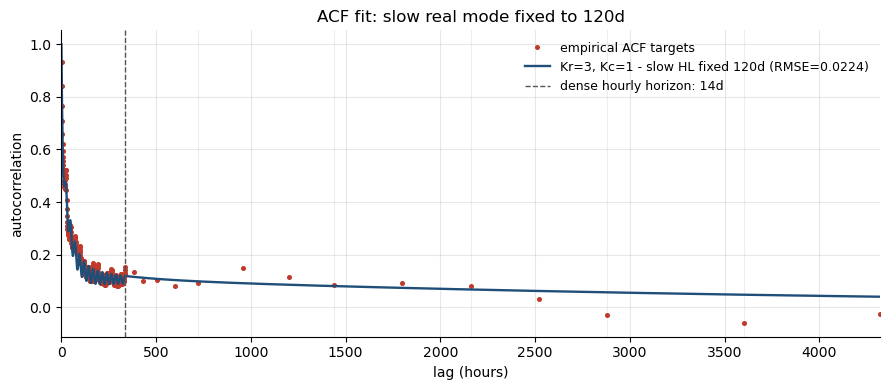

In [16]:
# ── Kr=3, Kc=1 with fixed 24h period + fixed slow real HL ─────────
Kr, Kc = 3, 1
m = Kr + Kc
om_c_fixed = np.array([2 * np.pi / 24.0])

SLOW_REAL_HALF_LIFE_FIXED_H = 120.0 * 24.0

# Calibration target: dense hourly short lags + sparse long anchors.
short_lags = np.arange(1, 337)
long_anchor_lags = np.array([
    384,   # 16d
    432,   # 18d
    504,   # 21d
    600,   # 25d
    720,   # 30d
    960,   # 40d
    1200,  # 50d
    1440,  # 60d
    1800,  # 75d
    2160,  # 90d
    2520,  # 105d
    2880,  # 120d
    3600,  # 150d
    4320,  # 180d
])

lags_fit = np.concatenate([short_lags, long_anchor_lags])
rho_emp_fit = np.array([acf(k) for k in lags_fit])

wts_fit = 1.0 / np.sqrt(lags_fit.astype(float))
wts_fit[lags_fit <= 72] *= 2.0
wts_fit[lags_fit >= 168] *= 2.0
wts_fit[lags_fit >= 720] *= 1.5
wts_fit[lags_fit >= 2160] *= 2.0

for anchor in [1, 6, 12, 18, 24, 30, 48, 72, 96, 120, 144, 168, 336]:
    wts_fit[lags_fit == anchor] *= 8.0

for anchor in [720, 1440, 2160, 2880, 3600, 4320]:
    wts_fit[lags_fit == anchor] *= 10.0

sw_fit = np.sqrt(wts_fit / wts_fit.mean())

lags = lags_fit
rho_emp = rho_emp_fit
sw = sw_fit

def unpack_theta_fixed_slow(theta):
    # theta = [log_hl_fast, log_hl_mid, log_hl_osc, share_logits_0..3]
    theta = np.asarray(theta, dtype=float)

    hl_real = np.array([
        np.exp(theta[0]),
        np.exp(theta[1]),
        SLOW_REAL_HALF_LIFE_FIXED_H,
    ])
    hl_osc = np.exp(theta[2])

    kap_real = np.log(2.0) / hl_real
    kap_osc = np.array([np.log(2.0) / hl_osc])
    sh = softmax(theta[3:3 + m])

    return hl_real, hl_osc, kap_real, kap_osc, sh

def rho_24(theta, k):
    hl_real, hl_osc, kap_real, kap_osc, sh = unpack_theta_fixed_slow(theta)
    h = np.asarray(k, dtype=float)

    out = np.zeros_like(h, dtype=float)
    for i in range(Kr):
        out += sh[i] * np.exp(-kap_real[i] * h)
    for j in range(Kc):
        idx = Kr + j
        out += sh[idx] * np.exp(-kap_osc[j] * h) * np.cos(om_c_fixed[j] * h)
    return out

# Optimised half-life bounds.
# The slow real mode is fixed, so it is not in theta.
max_half_life_h = 30.0 * 24.0

lb = [
    np.log(0.3),              # real fast
    np.log(0.3),              # real mid
    np.log(12.0),             # oscillatory daily HL
] + [-9.0] * m

ub = [
    np.log(max_half_life_h),  # real fast <= 30d
    np.log(max_half_life_h),  # real mid <= 30d
    np.log(max_half_life_h),  # oscillatory <= 30d
] + [9.0] * m

start_hl = [
    [2.0, 24.0, 72.0],
    [4.0, 36.0, 96.0],
    [1.0, 12.0, 48.0],
    [6.0, 48.0, 120.0],
    [3.0, 30.0, 96.0],
    [8.0, 36.0, 96.0],
    [10.0, 36.0, 120.0],
]

rng = np.random.default_rng(42)
best = None
n_starts = 80

print(f"Fixed slow real half-life = {SLOW_REAL_HALF_LIFE_FIXED_H:.1f} h = {SLOW_REAL_HALF_LIFE_FIXED_H / 24.0:.1f} d")
print(f"ACF calibration lags: {len(lags_fit)}")
print(f"  short dense lags: {short_lags[0]}..{short_lags[-1]} h")
print(f"  long anchors h: {long_anchor_lags.tolist()}")

for s in range(n_starts):
    if s < len(start_hl):
        xs = np.r_[np.log(start_hl[s]), [0.0] * m]
    else:
        xs = np.r_[np.log(start_hl[s % len(start_hl)]), [0.0] * m]
        xs[:3] += rng.normal(0, 0.65, 3)
        xs[3:3 + m] += rng.normal(0, 1.2, m)

    xs = np.clip(xs, lb, ub)

    r = least_squares(
        lambda t: sw_fit * (rho_24(t, lags_fit) - rho_emp_fit),
        xs,
        bounds=(lb, ub),
        max_nfev=9000,
    )
    if best is None or r.cost < best.cost:
        best = r

hl_real_b, hl_osc_b, kap_r, kap_c, sh_b = unpack_theta_fixed_slow(best.x)
kap_b = np.r_[kap_r, kap_c]
hl_best = np.r_[hl_real_b, hl_osc_b]

active_upper = np.array([
    np.isclose(hl_real_b[0], max_half_life_h, rtol=0, atol=1e-4),
    np.isclose(hl_real_b[1], max_half_life_h, rtol=0, atol=1e-4),
    False,
    np.isclose(hl_osc_b, max_half_life_h, rtol=0, atol=1e-4),
])

print("Best half-lives h [real fast, real mid, real slow fixed, osc]:", np.round(hl_best, 3))
print("Best half-lives d [real fast, real mid, real slow fixed, osc]:", np.round(hl_best / 24.0, 3))
print("Active upper bound:", active_upper)
print("Optimizer status:", best.status, best.message)

rows = []
for i in range(Kr):
    hl_h = hl_real_b[i]
    rows.append({
        "kind": "real_fixed" if i == 2 else "real",
        "half_life_h": hl_h,
        "half_life_d": hl_h / 24.0,
        "period_h": np.inf,
        "share": sh_b[i],
    })
for j in range(Kc):
    idx = Kr + j
    hl_h = hl_osc_b
    rows.append({
        "kind": "osc",
        "half_life_h": hl_h,
        "half_life_d": hl_h / 24.0,
        "period_h": 24.0,
        "share": sh_b[idx],
    })

summary_24 = pd.DataFrame(rows).sort_values(["kind", "half_life_h"]).reset_index(drop=True)
display(summary_24.style.format({
    "half_life_h": "{:.2f}",
    "half_life_d": "{:.2f}",
    "period_h": "{:.1f}",
    "share": "{:.3f}",
}).hide(axis="index"))

rmse_24 = float(np.sqrt(np.mean((rho_24(best.x, lags_fit) - rho_emp_fit) ** 2)))
wssr_24 = float(np.sum((sw_fit * (rho_24(best.x, lags_fit) - rho_emp_fit)) ** 2))
print(f"RMSE={rmse_24:.6f}  WSSR={wssr_24:.4f}  (CARMA order {Kr + 2 * Kc})")

diag = [1, 2, 3, 6, 12, 18, 24, 30, 48, 72, 96, 120, 144, 168, 240, 336]
cmp = pd.DataFrame({
    "lag_h": diag,
    "empirical": [acf(k) for k in diag],
    "model": rho_24(best.x, np.array(diag, dtype=float)),
})
cmp["err"] = cmp["model"] - cmp["empirical"]
display(cmp.style.format({
    "empirical": "{:.4f}",
    "model": "{:.4f}",
    "err": "{:+.4f}",
}).hide(axis="index"))

diag_long = list(long_anchor_lags)
cmp_long = pd.DataFrame({
    "lag_h": diag_long,
    "days": np.array(diag_long) / 24.0,
    "empirical": [acf(k) for k in diag_long],
    "model": rho_24(best.x, np.array(diag_long, dtype=float)),
})
cmp_long["err"] = cmp_long["model"] - cmp_long["empirical"]

print("Long-lag anchors included in calibration.")
display(cmp_long.style.format({
    "days": "{:.1f}",
    "empirical": "{:.4f}",
    "model": "{:.4f}",
    "err": "{:+.4f}",
}).hide(axis="index"))

kk = np.unique(np.r_[np.arange(0, 337), np.arange(360, int(lags_fit.max()) + 1, 24)])
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(lags_fit, rho_emp_fit, "o", ms=2.6, color="#c0392b", label="empirical ACF targets")
ax.plot(kk, rho_24(best.x, kk), "-", lw=1.7, color="#1f4e79",
        label=f"Kr=3, Kc=1 - slow HL fixed 120d (RMSE={rmse_24:.4f})")

for d in [336, 720, 1440, 2160, 2880, 3600, 4320]:
    ax.axvline(d, color="#eee", lw=0.8, zorder=0)
ax.axvline(336, color="#555555", lw=1.0, ls="--", label="dense hourly horizon: 14d")

ax.set_xlim(0, int(lags_fit.max()))
ax.set_xlabel("lag (hours)")
ax.set_ylabel("autocorrelation")
ax.set_title("ACF fit: slow real mode fixed to 120d")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

P(u) degree=4  leading=2.2408e-04  (expected 2v0·Σκw=2.2408e-04)
All b roots Re<0: True  |  max Re=-1.10e-03
b = [7.835423e-06, 7.187126e-03, 7.131652e-02, 1.304485e-01, 1.000000e+00]
b^T·P_norm·b = 5.6090e+00  (v0=1.2568e-03)

=== ACF verification ===
  Multiscale model  RMSE=0.022391  WSSR=0.2742
  Spectral b        RMSE=0.022391  WSSR=0.2742
  ΔRMSE = 2.58e-12  (should be ≈0)


lag_h,empirical,multiscale,"CARMA(5,4) sf-b",err_sf
1,0.9332,0.9183,0.9183,-0.0149
2,0.8402,0.8488,0.8488,0.0086
3,0.7650,0.7883,0.7883,0.0233
6,0.6222,0.6433,0.6433,0.0211
12,0.5136,0.4805,0.4805,-0.0330
18,0.4529,0.4679,0.4679,0.0150
24,0.5224,0.4679,0.4679,-0.0545
30,0.3249,0.3765,0.3765,0.0517
48,0.3143,0.3282,0.3282,0.0139
72,0.2722,0.2483,0.2483,-0.0239


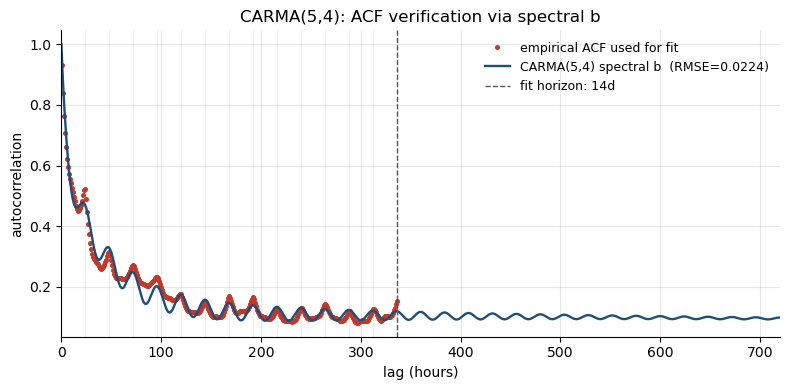

saved: price_multiscale_carma_selected.json
saved: price_carma_b_init.json
saved: price_multiscale_carma_selected_components.csv

=== Init for nb03: p=5, q=4 ===
  b = [7.835423e-06, 7.187126e-03, 7.131652e-02, 1.304485e-01, 1.000000e+00]


In [17]:
# ── Spectral factorisation CARMA(5,4) + save ─────────────────────
kap_r = kap_b[:Kr]
sh_r = sh_b[:Kr]
kap_c = kap_b[Kr:]
sh_c = sh_b[Kr:]
om_c = om_c_fixed.copy()
p = Kr + 2 * Kc

roots_ar = [complex(-kap_r[i], 0.0) for i in range(Kr)]
for j in range(Kc):
    roots_ar.extend([
        complex(-kap_c[j], om_c[j]),
        complex(-kap_c[j], -om_c[j]),
    ])
ar = np.real(np.poly(roots_ar)[1:])

A = np.zeros((p, p))
for i in range(p - 1):
    A[i, i + 1] = 1.0
A[-1, :] = -ar[::-1]
ep = np.zeros(p)
ep[-1] = 1.0
P_norm = solve_continuous_lyapunov(A, -np.outer(ep, ep))

fp_r2 = lambda k: np.array([1.0, k ** 2])
fp_c2 = lambda k, o: np.array([1.0, 2 * (k ** 2 - o ** 2), (k ** 2 + o ** 2) ** 2])
fr2 = [fp_r2(k) for k in kap_r]
fc2 = [fp_c2(k, o) for k, o in zip(kap_c, om_c)]

P_u = np.zeros(p)
for i in range(Kr):
    t = np.array([2 * kap_r[i] * sh_r[i] * v0])
    for i2 in range(Kr):
        if i2 != i:
            t = np.polymul(t, fr2[i2])
    for j in range(Kc):
        t = np.polymul(t, fc2[j])
    P_u = np.polyadd(P_u, t)

for j in range(Kc):
    t = np.polymul(
        np.array([2 * kap_c[j] * sh_c[j] * v0]),
        np.array([1.0, kap_c[j] ** 2 + om_c[j] ** 2]),
    )
    for i in range(Kr):
        t = np.polymul(t, fr2[i])
    for j2 in range(Kc):
        if j2 != j:
            t = np.polymul(t, fc2[j2])
    P_u = np.polyadd(P_u, t)

print(f"P(u) degree={len(P_u) - 1}  leading={P_u[0]:.4e}  "
      f"(expected 2v0·Σκw={2 * v0 * float(np.r_[kap_r, kap_c] @ sh_b):.4e})")

u_roots = np.roots(P_u)
b_roots = np.array([
    1j * np.sqrt(uk) if np.real(1j * np.sqrt(uk)) < np.real(-1j * np.sqrt(uk))
    else -1j * np.sqrt(uk)
    for uk in u_roots
])
print(f"All b roots Re<0: {np.all(np.real(b_roots) < 0)}  |  max Re={np.max(np.real(b_roots)):.2e}")

b_vec_raw = np.real(np.poly(b_roots)[::-1])
b_vec = b_vec_raw / b_vec_raw[-1]   # book convention: monic highest MA coefficient b_q = 1
Pb = P_norm @ b_vec
var0 = float(b_vec @ Pb)
print(f"b = {np.array2string(b_vec, precision=6, separator=', ')}")
print(f"b^T·P_norm·b = {var0:.4e}  (v0={v0:.4e})")

eAh = np.stack([expm(A * float(h)) for h in lags])
rho_sf = (eAh @ Pb) @ b_vec / var0
rmse_sf = float(np.sqrt(np.mean((rho_sf - rho_emp) ** 2)))
wssr_sf = float(np.sum((sw * (rho_sf - rho_emp)) ** 2))
print("\n=== ACF verification ===")
print(f"  Multiscale model  RMSE={rmse_24:.6f}  WSSR={wssr_24:.4f}")
print(f"  Spectral b        RMSE={rmse_sf:.6f}  WSSR={wssr_sf:.4f}")
print(f"  ΔRMSE = {rmse_sf - rmse_24:.2e}  (should be ≈0)")

diag = [1, 2, 3, 6, 12, 18, 24, 30, 48, 72, 96, 120, 144, 168, 240, 336]
eAhd = np.stack([expm(A * float(h)) for h in diag])
cmp = pd.DataFrame({
    "lag_h": diag,
    "empirical": [acf(k) for k in diag],
    "multiscale": rho_24(best.x, np.array(diag, dtype=float)),
    f"CARMA({p},{p-1}) sf-b": (eAhd @ Pb) @ b_vec / var0,
})
cmp["err_sf"] = cmp[f"CARMA({p},{p-1}) sf-b"] - cmp["empirical"]
display(cmp.style.format({c: "{:.4f}" for c in cmp.columns[1:]}).hide(axis="index"))

kk = np.arange(0, 721)
eAhp = np.stack([expm(A * float(h)) for h in kk])
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, 337), [acf(k) for k in range(1, 337)],
        "o", ms=2.6, color="#c0392b", label="empirical ACF used for fit")
ax.plot(kk, (eAhp @ Pb) @ b_vec / var0, "-", lw=1.7, color="#1f4e79",
        label=f"CARMA({p},{p-1}) spectral b  (RMSE={rmse_sf:.4f})")
for d in range(24, 337, 24):
    ax.axvline(d, color="#eee", lw=0.8, zorder=0)
ax.axvline(336, color="#555555", lw=1.0, ls="--", label="fit horizon: 14d")
ax.set_xlim(0, 720)
ax.set_xlabel("lag (hours)")
ax.set_ylabel("autocorrelation")
ax.set_title(f"CARMA({p},{p-1}): ACF verification via spectral b")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

def _ser(x):
    return None if (isinstance(x, float) and not np.isfinite(x)) else float(x)

components = [
    {
        "kind": str(r["kind"]),
        "half_life_h": float(r["half_life_h"]),
        "half_life_d": float(r["half_life_d"]),
        "period_h": _ser(r["period_h"]),
        "share": float(r["share"]),
    }
    for _, r in summary_24.iterrows()
]

payload = dict(
    selected=dict(Kr=Kr, Kc=Kc, order=p),
    roots=[[float(r.real), float(r.imag)] for r in roots_ar],
    ar_coefficients=[float(x) for x in ar],
    b_coefficients=[float(x) for x in b_vec],
    metrics=dict(
        rmse_multiscale=float(rmse_24),
        wssr_multiscale=float(wssr_24),
        rmse_spectral=float(rmse_sf),
        wssr_spectral=float(wssr_sf),
    ),
    components=components,
    calibration=dict(
        acf_fit_horizon_h=int(lags_fit.max()),
        acf_fit_horizon_d=float(lags_fit.max() / 24.0),
        acf_diagnostic_horizon_h=int(lags_diag.max()),
        acf_diagnostic_horizon_d=float(lags_diag.max() / 24.0),
        max_half_life_h=float(max_half_life_h),
        max_half_life_d=float(max_half_life_h / 24.0),
        n_fit_lags=int(len(lags_fit)),
    ),
    note="Kr=3 Kc=1 period=24h fixed; ACF fit on 1h-336h; all half-lives <= 30 days. CARMA(5,4). Monic b[-1]=1 (book convention).",
)
(OUT / "price_multiscale_carma_selected.json").write_text(json.dumps(payload, indent=2))
(OUT / "price_carma_b_init.json").write_text(json.dumps(dict(
    b_coefficients=[float(x) for x in b_vec],
    AR_order=int(p),
    MA_order=int(p - 1),
    acf_rmse_spectral=float(rmse_sf),
    acf_rmse_multiscale=float(rmse_24),
    note=f"CARMA({p},{p-1}) spectral b from 14-day ACF calibration. Monic b[-1]=1 (book convention).",
), indent=2))

summary_24.to_csv(OUT / "price_multiscale_carma_selected_components.csv", index=False)
print("saved: price_multiscale_carma_selected.json")
print("saved: price_carma_b_init.json")
print("saved: price_multiscale_carma_selected_components.csv")
print(f"\n=== Init for nb03: p={p}, q={p - 1} ===")
print(f"  b = {np.array2string(b_vec, precision=6, separator=', ')}")